In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
data = [
    ["Dataset_A", "fMRI", "navigation_accuracy", 120, True, True],
    ["Dataset_B", "fMRI", "mental_rotation", 85, True, True],
    ["Dataset_C", "EEG-fMRI", "path_efficiency", 64, True, True],
    ["Dataset_D", "MEG", "reaction_time", 52, True, False],
    ["Dataset_E", "fMRI", "landmark_memory", 78, True, True],
    ["Dataset_F", "behavioral", "orientation_score", 140, False, True]
]

df = pd.DataFrame(
    data,
    columns=[
        "dataset",
        "modality",
        "target_variable",
        "n_subjects",
        "network_features",
        "behavior_labels"
    ]
)

df

,dataset,modality,target_variable,n_subjects,network_features,behavior_labels
0,Dataset_A,fMRI,navigation_accuracy,120,True,True
1,Dataset_B,fMRI,mental_rotation,85,True,True
2,Dataset_C,EEG-fMRI,path_efficiency,64,True,True
3,Dataset_D,MEG,reaction_time,52,True,False
4,Dataset_E,fMRI,landmark_memory,78,True,True
5,Dataset_F,behavioral,orientation_score,140,False,True


In [4]:
summary = (
    df.groupby("target_variable")["n_subjects"]
    .sum()
    .reset_index()
    .sort_values("n_subjects", ascending=False)
)

summary

,target_variable,n_subjects
3,orientation_score,140
2,navigation_accuracy,120
1,mental_rotation,85
0,landmark_memory,78
4,path_efficiency,64
5,reaction_time,52


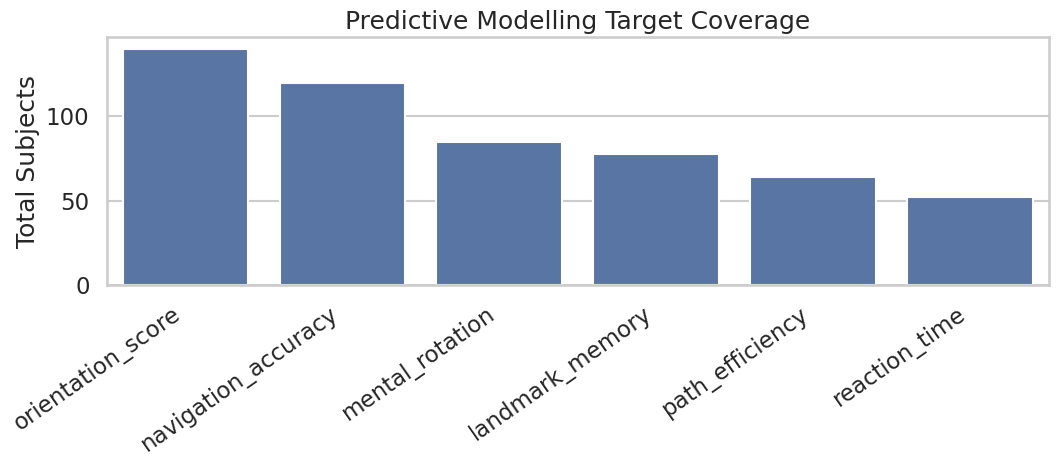

In [5]:
plt.figure(figsize=(11,5))

sns.barplot(
    data=summary,
    x="target_variable",
    y="n_subjects"
)

plt.xticks(rotation=35, ha="right")
plt.xlabel("")
plt.ylabel("Total Subjects")
plt.title("Predictive Modelling Target Coverage")
plt.tight_layout()
plt.savefig("figures/01_target_landscape.png", dpi=300)
plt.show()

In [6]:
ready = df[
    (df["network_features"] == True) &
    (df["behavior_labels"] == True)
]

ready.to_csv("outputs/01_ready_predictive_datasets.csv", index=False)
df.to_csv("outputs/01_full_predictive_landscape.csv", index=False)

ready

,dataset,modality,target_variable,n_subjects,network_features,behavior_labels
0,Dataset_A,fMRI,navigation_accuracy,120,True,True
1,Dataset_B,fMRI,mental_rotation,85,True,True
2,Dataset_C,EEG-fMRI,path_efficiency,64,True,True
4,Dataset_E,fMRI,landmark_memory,78,True,True
